# Decision Tree Classifier — Phase 2
Multi-class classification on MNIST: all **10 digit classes** (0–9).

## Decision Tree Algorithm

A decision tree is a non-parametric supervised model that classifies a sample by sending it down a sequence of binary tests on individual feature values until it reaches a leaf, which holds a class label.

### How the Tree Is Built

Construction proceeds **top-down** and **greedily** from the root:

1. Start with the entire training set at the root.
2. Search the available features for the **single feature + threshold pair** that produces the purest possible split — the one that lowers the weighted impurity of the children the most.
3. Partition the data into a left child (rows where `feature < threshold`) and a right child (rows where `feature >= threshold`).
4. Recurse on each child, repeating steps 2–3.
5. Stop when no further useful split can be made and turn the node into a **leaf** that predicts the majority class of the samples that reached it.

### Splitting Criterion

At every internal node we evaluate every candidate split with the **Gini impurity** of the resulting children (formal definition in the next section). To keep training tractable, threshold candidates are computed as **midpoints** between consecutive sorted unique values per feature, and roughly every 10th midpoint is sampled — a common speed/quality trade-off for trees on continuous inputs.

### Recursive Structure

The tree is naturally recursive: each internal node is itself the root of a smaller decision tree built on a subset of the training data. The implementation reflects this directly — `_build_tree(X, y, depth)` calls itself on the left and right partitions and returns a `DecisionTreeNode` linking the two sub-trees together.

### Stopping Conditions

Recursion halts (and the node becomes a leaf) whenever any of the following is true:

- **Maximum depth reached** — `depth >= max_depth`. Prevents unbounded growth and acts as the main regulariser against overfitting.
- **Too few samples to split** — `n_samples < min_samples`. A node with very few examples cannot produce a statistically meaningful split.
- **Pure node** — `len(np.unique(y)) == 1`. All remaining samples already share the same label, so further splitting cannot improve purity.
- **No useful split exists** — `_best_split` returns `None`, e.g. when every candidate threshold would leave one of the children below `min_samples_leaf`.

When any of these triggers, the leaf is labelled with the majority class of the samples that reached it.

Unlike phase 1, class weights are not needed since the 10 classes are balanced by default.

## Loss Function — Gini Impurity

Decision trees do not minimise a global differentiable loss the way logistic regression or neural networks do. Instead, every candidate split is scored by an **impurity function** measured on the resulting children, and the split with the lowest weighted impurity is chosen greedily. This implementation uses the **Gini index**.

### Definition and Formula

For a node containing samples from $K$ classes with class proportions $p_1, p_2, \dots, p_K$, the Gini impurity is

$$
G \;=\; 1 \;-\; \sum_{k=1}^{K} p_k^{\,2}.
$$

For the 10-class problem ($K = 10$), a perfectly uniform node would give $G = 1 - 10 \times (0.1)^2 = 0.9$, the maximum possible impurity.

The score of a candidate split is the **weighted Gini of the children**:

$$
G_{\text{split}} \;=\; \frac{n_L}{n_L + n_R}\,G_L \;+\; \frac{n_R}{n_L + n_R}\,G_R,
$$

where $n_L$ and $n_R$ are the sizes of the left and right partitions. The split that minimises $G_{\text{split}}$ wins.

### Intuition Behind Impurity

Gini measures the probability of misclassifying a randomly drawn sample if we labelled it according to the class distribution at the node:

- A **pure** node — every sample shares the same class — has $p_k = 1$ for one class and $0$ elsewhere, giving $G = 0$.
- A **maximally impure** node — uniform mix of all 10 classes — gives $G = 0.9$.

So smaller Gini ⇒ purer node ⇒ more confident prediction at the leaf. Choosing the split that minimises children's Gini is therefore a direct, local proxy for maximising classification confidence.

### Why Gini for Classification Trees

- **Designed for discrete labels.** Gini operates directly on class proportions, unlike regression-style losses (MSE, MAE) that need a numeric target.
- **Cheap to compute.** It only needs class counts, no logarithms — slightly faster than entropy in the inner loop, with empirically very similar splits.
- **Scales naturally to multi-class.** The same formula handles $K = 2$ (Phase 1) and $K = 10$ (Phase 2) without modification — only the number of terms in the sum changes.

In [ ]:
import numpy as np

class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, label=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.label = label


class CustomDecisionTree:
    def __init__(self, max_depth=10, min_samples=5, n_features=None , min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.n_features = n_features
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    def fit(self, X, y):
        np.random.seed(42)
        self.n_classes = len(np.unique(y))
        self.n_features_total = X.shape[1]
        self.n_features = self.n_features or self.n_features_total
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples = X.shape[0]

        # stopping conditions
        if (
            depth >= self.max_depth or
            n_samples < self.min_samples or
            len(np.unique(y)) == 1
        ):
            return DecisionTreeNode(label=self._majority_label(y))

        feature_idxs = np.random.choice(self.n_features_total, self.n_features, replace=False)

        best_feature, best_threshold = self._best_split(X, y, feature_idxs)

        if best_feature is None:
            return DecisionTreeNode(label=self._majority_label(y))

        left_mask = X[:, best_feature] < best_threshold
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return DecisionTreeNode(best_feature, best_threshold, left, right)

    def _best_split(self, X, y, feature_idxs):
        best_gini = float("inf")
        best_feature, best_threshold = None, None

        for feature in feature_idxs:
            X_col = X[:, feature]
            unique_vals = np.unique(X_col)

            if len(unique_vals) == 1:
                continue

            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2

            step = max(1, len(thresholds) // 10)

            for t in thresholds[::step]:
                gini = self._gini_split(y, X_col, t)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    def _gini_split(self, y, X_col, threshold):
        left = y[X_col < threshold]
        right = y[X_col >= threshold]

        if len(left) < self.min_samples_leaf or len(right) < self.min_samples_leaf:
            return float("inf")

        def gini(group):
            if len(group) == 0:
                return 0

            classes, counts = np.unique(group, return_counts=True)

            probs = counts / np.sum(counts)
            return 1 - np.sum(probs ** 2)

        n = len(y)
        return (len(left)/n)*gini(left) + (len(right)/n)*gini(right)

    def _majority_label(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.label is not None:
            return node.label

        if x[node.feature] < node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)

## Preprocessing — Five Feature Representations

Before training, each MNIST image is converted into a feature vector. Phase 2 expands the comparison from three representations (Phase 1) to **five**, adding pretrained CNN features and a HOG+PCA hybrid. All are produced by the shared `preprocess(...)` helper.

### 1. Flattening
The raw 28×28 image is unrolled into a length-784 vector of normalised pixel intensities. **No information is discarded** — every pixel becomes its own feature. Trees split on individual features and don't suffer from feature correlation, so the high dimensionality and redundancy among neighbouring pixels are not a problem.

### 2. PCA
Principal Component Analysis projects the 784 flattened pixels onto their **top 50 principal components** — the directions of greatest variance. The result is a compact, decorrelated 50-dim feature vector that retains roughly 80–85% of total variance.

### 3. HOG
Histogram of Oriented Gradients computes local edge-orientation histograms over small image patches. Instead of pixel intensities, each feature describes the **direction and strength of edges** in a region, producing ~324 features.

### 4. HOG + PCA
HOG features are further reduced by PCA to 50 components. This combines HOG's structural description with PCA's dimensionality reduction.

### 5. Pretrained CNN Features
A pretrained convolutional neural network extracts high-level feature embeddings from each image. These features capture abstract patterns learned from large-scale training — edges, textures, and shapes — compressed into a dense vector representation.

The cell below reloads the `preprocessing2` module so that any local edits are picked up without restarting the kernel.

In [ ]:
import importlib
import preprocessing2
importlib.reload(preprocessing2)

## Grid Search Cross-Validation

This section runs a comprehensive **grid search** over both the preprocessing pipeline and the tree's structural hyperparameters to find the best configuration for 10-class MNIST.

### Hyperparameters Tuned

| Axis | Values | Purpose |
|------|--------|---------|
| Feature representation | `flatten`, `pca`, `hog`, `hog_pca`, `cnn` | Controls what the tree sees as input |
| `max_depth` | 8, 10, 12 | Limits tree growth — deeper trees are more expressive but risk overfitting |
| `min_samples` | 2, 10, 20 | Minimum samples to allow a node to split — higher values regularise more |
| `min_samples_leaf` | 1, 3 | Minimum samples in each child — prevents tiny leaves |
| `n_features` | $\sqrt{d}$, $d/2$, $d$ | How many features are randomly considered per split |

This gives **5 × 3 × 3 × 2 × 3 = 270 total configurations**, each evaluated with **3-fold cross-validation** (810 total tree fits).

### Selection Procedure

For each of the 270 combinations:

1. Load the data with the chosen feature method via `preprocess(...)`.
2. Split the training set into 3 folds with `k_fold_indices`.
3. Train one tree per fold, predict on the held-out fold.
4. Compute the **Macro F1 score** (averaged equally across all 10 classes) for each fold, then average across folds.

Macro F1 is used instead of raw accuracy because it weights all 10 classes equally regardless of their sample count, giving a fairer picture of multi-class performance. After all 270 runs, the configuration with the highest mean Macro F1 is selected.


In [ ]:
from preprocessing2 import preprocess, custom_classification_report, custom_confusion_matrix, custom_accuracy_score, k_fold_indices, custom_macro_f1_score
import numpy as np

feature_methods = ["cnn", "hog", "pca","flatten", "hog_pca"]


best_f1_score = 0
best_params = {}

current_run = 1

for feature_method in feature_methods:
    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=feature_method,
        n_pca=50,
        cv = True
    )

    folds = k_fold_indices(X_train, k=3)

    param_grid = {
    'max_depth': [8, 10, 12],
    'min_samples': [2, 10,20],
    'min_samples_leaf' : [1, 3],
    'n_features': [int(np.sqrt(X_train.shape[1])), X_train.shape[1] // 2, X_train.shape[1]]
    }
    total_runs = len(feature_methods) * len(param_grid['max_depth']) * len(param_grid['min_samples']) * len(param_grid['n_features']) * len(param_grid['min_samples_leaf'])

    for depth in param_grid['max_depth']:
        for min_s in param_grid['min_samples']:
            for min_leaf in param_grid['min_samples_leaf']:
                for n_feat in param_grid['n_features']:

                    print(f"--- Run {current_run}/{total_runs} | Feature:{feature_method} | Depth:{depth} | MinSamples:{min_s} | MinSampleLeaf:{min_leaf} | n_feat:{n_feat} ---")

                    fold_f1_scores = []

                    for train_idx, val_idx in folds:
                        X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
                        X_fold_val, y_fold_val = X_train[val_idx], y_train[val_idx]

                        cv_model = CustomDecisionTree(
                            max_depth=depth,
                            min_samples=min_s,
                            min_samples_leaf=min_leaf,
                            n_features=min(n_feat, X_train.shape[1]),
                        )

                        cv_model.fit(X_fold_train, y_fold_train)
                        preds = cv_model.predict(X_fold_val)

                        fold_f1 = custom_macro_f1_score(y_fold_val, preds, n_classes=10)
                        fold_f1_scores.append(fold_f1)

                    avg_f1 = np.mean(fold_f1_scores)
                    print(f"    -> 3-Fold Average Macro F1: {avg_f1:.4f}\n")

                    if avg_f1 > best_f1_score:
                        best_f1_score = avg_f1
                        best_params = {
                            'feature_method': feature_method,
                            'max_depth': depth,
                            'min_samples': min_s,
                            'min_samples_leaf': min_leaf,
                            'n_features': n_feat
                        }

                    current_run += 1

print("="*50)
print("  GRID SEARCH COMPLETE")
print("="*50)
print(f"Best CV Macro F1: {best_f1_score:.4f}")
print(f"Best Parameters: {best_params}")

## Grid Search Results

After evaluating all 270 configurations, the grid search selected:

| Setting | Best Value |
|---------|------------|
| Feature method | `flatten` |
| `max_depth` | 12 |
| `min_samples` | 10 |
| `min_samples_leaf` | 3 |
| `n_features` | 784 (all features) |
| **Best CV Macro F1** | **0.8584** |

### Key Observations

**Flatten consistently outperformed HOG and PCA across most hyperparameter settings.** The top runs for each feature method were:

- `flatten` best: Macro F1 ≈ 0.8578 (depth=12, min_samples=10)
- `hog` best: Macro F1 ≈ 0.8371 (depth=12, min_samples=2)
- `pca` / `hog_pca` / `cnn`: lower than both

**Deeper trees performed better** — `max_depth=12` consistently beat 8 and 10, indicating the 10-class problem needs more splits to separate visually similar digits (3 vs 8, 4 vs 9). However, the `min_samples_leaf=3` constraint was selected over `min_samples_leaf=1`, showing the grid search found a balance between expressiveness and regularisation.

**Using all features (`n_features=784`) beat the subsampled options** ($\sqrt{784} = 28$ and $784/2 = 392$). Unlike a Random Forest — where random feature subsampling introduces diversity across trees — a standalone decision tree benefits from seeing all features at every split to make the best possible greedy choice.

### Why Flattening Won — Even for 10-Class

One might expect flattening to lose its advantage when scaling from 2 classes to 10. In Phase 1, the binary 0-vs-Not-0 task was simple enough that *any* feature set could reach ~98% accuracy, so the question was somewhat academic. With 10 classes, the tree must separate visually similar digits — 3 vs 8, 4 vs 9, 5 vs 6 — where structural features (HOG) might seem more useful. Yet flattening still won. Several factors explain this:

- **MNIST is pre-aligned and centred.** Every digit sits in the same position within the 28×28 grid. This means pixel position is directly meaningful: pixel (13, 14) is consistently in the centre of every image regardless of digit class. Trees exploit this perfectly — a single test like "is the centre pixel dark?" gives a clean split. HOG deliberately discards this positional information by converting to gradient histograms, solving a problem (translation/scale invariance) that MNIST simply doesn't have.

- **Trees make axis-aligned splits.** Each internal node asks *"is feature $j$ > threshold?"*. With flattened pixels, feature $j$ is a specific spatial location — a geometrically interpretable question. With PCA, feature $j$ is a dense weighted sum of all 784 pixels, and with HOG, it's a gradient histogram bin over a patch. These transformed axes are less directly discriminative for the tree's axis-aligned splitting mechanism.

- **No information is discarded.** Flatten keeps 100% of the pixel data (784 features). PCA at 50 components retains roughly 80–85% of variance and irreversibly discards the rest. HOG collapses within-patch positional detail into orientation bins (~324 features). For distinguishing 3 vs 8, the *exact position* of where the top curve closes — a few specific pixels — is the discriminative signal, and flatten preserves it while HOG and PCA may dilute or discard it.

- **Trees handle uninformative features for free.** The outer border pixels are near-constant black for all digits. With flatten, the tree simply never selects them for splits (their Gini reduction is zero) — they cost nothing. With PCA, these low-variance pixels get mixed into every principal component, adding noise to otherwise useful features.

- **The depth-12 budget is spent on direct questions.** With `max_depth=12`, the tree asks at most 12 consecutive binary questions. Each question on a raw pixel is a directly meaningful geometric test; each question on a PCA component is an indirect test on a linear sketch of the whole image. The same depth budget yields more discriminative power with direct pixel questions.

- **HOG's advantage requires problems MNIST doesn't have.** HOG was designed for real-world images with varying positions, scales, and lighting. MNIST's preprocessing already solved all of these — digits are centred, size-normalised, and uniformly lit. HOG's invariance properties address non-existent variability at the cost of discarding the exact spatial information the tree needs.



## Final Evaluation using best parameters
### Training

In [23]:
from preprocessing2 import preprocess, custom_classification_report, custom_confusion_matrix, custom_accuracy_score
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="flatten",n_pca=50)  # balance=True for Phase 1, False for Phase 2

import time

# 2. Initialize model
print("Initializing Custom Decision Tree...")
tree = CustomDecisionTree(
    max_depth=12,
    min_samples=10,
    min_samples_leaf=3,
    n_features=X_train.shape[1],          
)

# 3. Train model
print("Training the model...")
start_time = time.time()
tree.fit(X_train, y_train)
print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

Split completed: Train=54000, Val=6000, Test=10000
Initializing Custom Decision Tree...
Training the model...
Training completed in 204.79 seconds.


### Testing

In [25]:
val_preds = tree.predict(X_val)

target_names = [str(i) for i in range(10)]
print(custom_classification_report(y_val, val_preds, target_names=target_names))

val_acc = custom_accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_acc:.4f}")

cm = custom_confusion_matrix(y_val, val_preds)

print("\nValidation Confusion Matrix (rows = actual, cols = predicted):\n")

labels = [str(i) for i in range(10)]

print(f"{'':12}", end="")
for label in labels:
    print(f"{label:>6}", end="")
print()

for i, row in enumerate(cm):
    print(f"{labels[i]:>10} ", end="")
    for val in row:
        print(f"{val:6}", end="")
    print()

print("\n" + "="*45)
print("  FINAL TEST PERFORMANCE")
print("="*45)

test_preds = tree.predict(X_test)

print(custom_classification_report(y_test, test_preds, target_names=target_names))

test_acc = custom_accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

cm_test = custom_confusion_matrix(y_test, test_preds)

print("\nTest Confusion Matrix (rows = actual, cols = predicted):\n")

print(f"{'':12}", end="")
for label in labels:
    print(f"{label:>6}", end="")
print()

for i, row in enumerate(cm_test):
    print(f"{labels[i]:>10} ", end="")
    for val in row:
        print(f"{val:6}", end="")
    print()

                 precision     recall   f1-score    support

0                     0.95       0.92       0.93        587
1                     0.95       0.96       0.95        630
2                     0.86       0.89       0.87        600
3                     0.86       0.84       0.85        627
4                     0.89       0.86       0.88        595
5                     0.86       0.81       0.84        549
6                     0.92       0.89       0.91        571
7                     0.90       0.95       0.92        668
8                     0.85       0.84       0.85        597
9                     0.82       0.90       0.86        576

accuracy                                    0.89       6000
macro avg             0.89       0.89       0.89       6000

Validation Accuracy: 0.8865

Validation Confusion Matrix (rows = actual, cols = predicted):

                 0     1     2     3     4     5     6     7     8     9
         0    540     0     7     7     2     6    

## Bias–Variance Analysis

To understand whether the model is underfitting (high bias) or overfitting (high variance), we plot a **learning curve**: the training and validation accuracy as a function of how much training data the model sees.

### The Idea Behind Bias and Variance

Every supervised model's prediction error can be decomposed into two components:

- **Bias** measures how far the model's average prediction is from the true value. A high-bias model is too simple to capture the patterns in the data — it **underfits**. Symptoms: both training and validation accuracy are low.

- **Variance** measures how much the model's predictions change when trained on different subsets of the data. A high-variance model is too sensitive to the specific training examples — it **overfits**, memorising noise instead of learning generalisable patterns. Symptoms: training accuracy is high but validation accuracy is much lower — a visible **gap** between the two curves.

### How Learning Curves Reveal Bias and Variance

The learning curve trains the model on increasing fractions of the data (10%, 20%, ..., 100%) and evaluates on a fixed validation set:

- **High bias (underfitting):** Both curves plateau at a low accuracy and converge close together. Adding more data doesn't help because the model is too simple.
- **High variance (overfitting):** The training curve stays high while the validation curve is noticeably lower. The gap between them is the signature of overfitting. Adding more data may help (the validation curve may rise slowly), but the gap persists.
- **Good fit:** Both curves converge at a high accuracy with a small gap between them.

### What to Expect From a Decision Tree

Decision trees are inherently **high-variance, low-bias** models — they can memorise the training data (low bias) but the learned structure is highly sensitive to which examples appear in the training set (high variance). We therefore expect to see a persistent gap between training and validation accuracy, which is the primary motivation for ensemble methods like Random Forest that reduce variance through bagging.

Split completed: Train=54000, Val=6000, Test=10000
Generating Learning Curves for CustomDecisionTree...
  Training on 5400 samples (10%)...
  Training on 10800 samples (20%)...
  Training on 16200 samples (30%)...
  Training on 21600 samples (40%)...
  Training on 27000 samples (50%)...
  Training on 32400 samples (60%)...
  Training on 37800 samples (70%)...
  Training on 43200 samples (80%)...
  Training on 48600 samples (90%)...
  Training on 54000 samples (100%)...


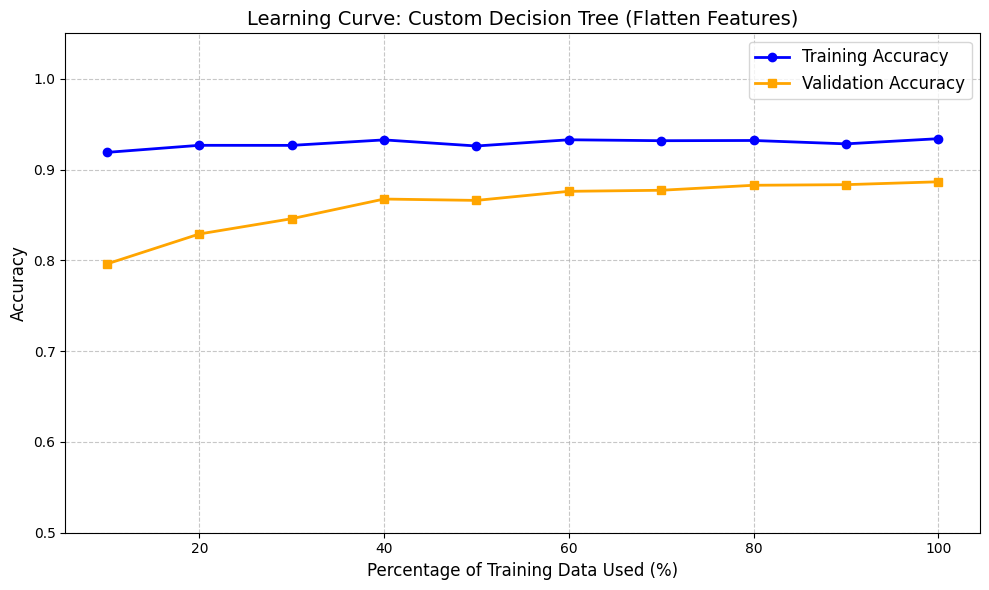


  BIAS-VARIANCE DIAGNOSIS
  Final Train Accuracy : 0.9340
  Final Val   Accuracy : 0.8865
  Gap (overfit measure): 0.0475

  >> GOOD FIT
     Train and val accuracy are close — well balanced


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing2 import custom_accuracy_score  # reuse your existing one

from preprocessing2 import preprocess  # or hog / cnn


X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="flatten")


# ─────────────────────────────────────────
# 3. LEARNING CURVE
# ─────────────────────────────────────────
train_fractions = np.linspace(0.1, 1.0, 10)
train_scores    = []
val_scores      = []

total_train_samples = len(X_train)

print("Generating Learning Curves for CustomDecisionTree...")
for fraction in train_fractions:
    subset_size = int(total_train_samples * fraction)
    print(f"  Training on {subset_size} samples ({int(fraction*100)}%)...")

    X_subset = X_train[:subset_size]
    y_subset = y_train[:subset_size]

    model = CustomDecisionTree(
        max_depth=12,
        min_samples=10,
        min_samples_leaf=3,
        n_features=784
    )
    model.fit(X_subset, y_subset)

    train_preds = model.predict(X_subset)
    val_preds   = model.predict(X_val)

    train_scores.append(custom_accuracy_score(y_subset, train_preds))
    val_scores.append(custom_accuracy_score(y_val,   val_preds))

# ─────────────────────────────────────────
# 4. PLOT
# ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(train_fractions * 100, train_scores,
         label="Training Accuracy",   color="blue",   marker="o", linewidth=2)
plt.plot(train_fractions * 100, val_scores,
         label="Validation Accuracy", color="orange",  marker="s", linewidth=2)

plt.title("Learning Curve: Custom Decision Tree (Flatten Features)", fontsize=14)
plt.xlabel("Percentage of Training Data Used (%)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.5, 1.05)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("learning_curve_tree.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# 5. BIAS-VARIANCE DIAGNOSIS (printed)
# ─────────────────────────────────────────
final_train = train_scores[-1]
final_val   = val_scores[-1]
gap         = final_train - final_val

print(f"\n{'='*45}")
print(f"  BIAS-VARIANCE DIAGNOSIS")
print(f"{'='*45}")
print(f"  Final Train Accuracy : {final_train:.4f}")
print(f"  Final Val   Accuracy : {final_val:.4f}")
print(f"  Gap (overfit measure): {gap:.4f}")

if final_train < 0.85:
    print("\n  >> HIGH BIAS (Underfitting)")
    print("     Try: increase max_depth, reduce min_samples")
elif gap > 0.08:
    print("\n  >> HIGH VARIANCE (Overfitting)")
    print("     Try: reduce max_depth, increase min_samples_leaf")
else:
    print("\n  >> GOOD FIT")
    print("     Train and val accuracy are close — well balanced")

### Learning Curve Results

The learning curve reveals the following:

- **Training accuracy** remains roughly flat at ~93% across all data fractions. The tree achieves high training accuracy even with only 10% of the data and does not improve much as more data is added — this is expected because the tree with `max_depth=12` and `min_samples_leaf=3` has enough capacity to fit the training data well regardless of subset size.

- **Validation accuracy** starts at ~80% with 10% of the data and rises steadily, reaching ~88–89% at 100%. The improvement is gradual and appears to be levelling off, suggesting that adding significantly more data would yield diminishing returns without changing the model.

- **The gap** between training (~93%) and validation (~88%) accuracy is approximately **5 percentage points**. This is a **moderate variance** signal — the tree is overfitting somewhat, but the regularisation from `min_samples=10` and `min_samples_leaf=3` keeps it under control. The gap is well below what an unrestricted tree (depth=unlimited, min_leaf=1) would produce, where training accuracy would approach 100%.

**Diagnosis: mild overfitting (moderate variance, low bias).** The training accuracy of ~93% shows the model has high accuracy (low bias). The ~5% gap shows some variance remains, which is characteristic of decision trees

## Verification With scikit-learn's Decision Tree


In [21]:
import numpy as np
import time
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    f1_score
)
from sklearn.decomposition import PCA
from skimage.feature import hog

# ─────────────────────────────────────────
# 1. LOAD & SPLIT MNIST
# ─────────────────────────────────────────
print("Loading MNIST...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

X_train_raw, X_test_raw = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

# ─────────────────────────────────────────
# 2. FEATURE EXTRACTION FUNCTIONS
# ─────────────────────────────────────────
def flatten_features(X):
    """Normalize and flatten."""
    return X / 255.0


def hog_features(X):
    """HOG on 28x28 images."""
    features = []

    for img in X:
        img_2d = img.reshape(28, 28) / 255.0

        fd = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        features.append(fd)

    return np.array(features)


# ─────────────────────────────────────────
# 3. PREPARE FEATURES
# ─────────────────────────────────────────
print("\nExtracting features...")

# ---------- Flatten ----------
t0 = time.time()

X_train_flat = flatten_features(X_train_raw)
X_test_flat  = flatten_features(X_test_raw)

print(f"Flatten done: {X_train_flat.shape[1]} features ({time.time()-t0:.1f}s)")

# ---------- HOG ----------
t0 = time.time()

X_train_hog = hog_features(X_train_raw)
X_test_hog  = hog_features(X_test_raw)

print(f"HOG done:     {X_train_hog.shape[1]} features ({time.time()-t0:.1f}s)")

# ---------- PCA ----------
print("\nApplying PCA...")

t0 = time.time()

# keep 95% variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

print(f"PCA done:     {X_train_pca.shape[1]} features ({time.time()-t0:.1f}s)")
print(f"Explained Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# ─────────────────────────────────────────
# 4. BEST HYPERPARAMS
# ─────────────────────────────────────────
BEST_PARAMS = {
    'max_depth': 12,
    'min_samples_split': 10,
    'min_samples_leaf': 1,
    'random_state': 42,
}

# ─────────────────────────────────────────
# 5. RUN COMPARISON
# ─────────────────────────────────────────
results = {}

feature_sets = [
    ('Flatten', X_train_flat, X_test_flat),
    ('HOG',     X_train_hog,  X_test_hog),
    ('PCA',     X_train_pca,  X_test_pca),
]

for feat_name, X_tr, X_te in feature_sets:

    print(f"\n{'='*55}")
    print(f"  SKLEARN DecisionTree | {feat_name}")
    print(f"{'='*55}")

    clf = DecisionTreeClassifier(**BEST_PARAMS)

    # ---------- Training ----------
    t0 = time.time()

    clf.fit(X_tr, y_train)

    train_time = time.time() - t0

    # ---------- Prediction ----------
    t0 = time.time()

    y_pred = clf.predict(X_te)

    pred_time = time.time() - t0

    # ---------- Metrics ----------
    acc = accuracy_score(y_test, y_pred)

    results[feat_name] = {
        'accuracy': acc,
        'train_time': train_time,
        'pred_time': pred_time,
        'y_pred': y_pred
    }

    # ---------- Output ----------
    print(f"Train time   : {train_time:.2f}s")
    print(f"Predict time : {pred_time:.2f}s")
    print(f"Test Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# ─────────────────────────────────────────
# 6. FINAL SUMMARY TABLE
# ─────────────────────────────────────────
print(f"\n{'='*70}")
print("FINAL COMPARISON SUMMARY")
print(f"{'='*70}")

print(
    f"{'Feature':<12}"
    f"{'Accuracy':>12}"
    f"{'Precision':>12}"
    f"{'F1 Macro':>12}"
    f"{'Train(s)':>12}"
)

print("-" * 60)

for name, r in results.items():

    acc  = accuracy_score(y_test, r['y_pred'])

    prec = precision_score(
        y_test,
        r['y_pred'],
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        r['y_pred'],
        average='macro'
    )

    print(
        f"{name:<12}"
        f"{acc:>12.4f}"
        f"{prec:>12.4f}"
        f"{f1:>12.4f}"
        f"{r['train_time']:>12.2f}"
    )

Loading MNIST...
Train: (60000, 784), Test: (10000, 784)

Extracting features...
Flatten done: 784 features (0.1s)
HOG done:     324 features (10.5s)

Applying PCA...
PCA done:     154 features (0.4s)
Explained Variance: 0.9502

  SKLEARN DecisionTree | Flatten
Train time   : 6.73s
Predict time : 0.01s
Test Accuracy: 0.8785

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       980
           1       0.96      0.96      0.96      1135
           2       0.86      0.86      0.86      1032
           3       0.83      0.85      0.84      1010
           4       0.88      0.85      0.86       982
           5       0.84      0.84      0.84       892
           6       0.90      0.87      0.89       958
           7       0.93      0.90      0.91      1028
           8       0.83      0.81      0.82       974
           9       0.83      0.87      0.85      1009

    accuracy                           0.88     10000
